# Лабораторная работа № 1

## Построение карты помещения (Occupancy grid mapping)

Требуется реализовать алгоритм построения карты помещения (occupancy grid mapping) на основе измерений лазерного дальномера, установленного на движущимся (на плоскости) мобильном объекте.

Данные организованы следующим образом:


- `poses.data`: содержит **известные** положения мобильного объекта. Каждая строка соответствует положению в текущий момент времени

- `ranges.data`: содержит результаты измерения лазерного дальномера. Каждая строка соответствует измерению расстояния из данного положения мобильного объекта.

---

### Конвертация логит функции в вероятность(Log odds to probability)

Расчеты удобнее проводить в терминах так называемой логит функции (логарифм отношения шансов - log odds). Для этого требуется конвертировать значения логит функции в вероятность и обратно. Требуется реализовать функции `logodds2prob`, `prob2logodds`.

---
### Обратная модель сенсора

Расчет вероятности занятости ячейки карты в алгоритме «occupancy grid mapping» основан на так называемой обратной модели сенсора.  Рассматривается упрощенная обратная модель сенсора, согласно которой вероятность занятости ячейки $m_i$ полагается равной заданному параметру $P_{occ}$, если данная ячейка находится в области покрытия наблюдения $z_t$, иначе эта вероятность полагается равной $P_{free}$.

В случае, если текущая ячейка $m_i$ находится вне зоны видимости сенсора, вероятность ее занятости полагается равной $P_{prior}$.

При проверке используются следующие значения параметров:
$$P_{occ} = 0.9, P_{free} = 0.35, P_{prior} = 0.5 $$


---
### Алгоритм «Occupancy grid mapping»:


Для реализации алгоритма используются следующие вспомогательные функции:


- `ranges2cells` конвертирует измерения, сделанные мобильным объект (*ranges_raw*), в соответствующие ячейки карты.
- `poses2cells` конвертирует положения мобильного объекта (*poses_raw*) в соответствующие ячейки карты.
- `bresenham` возвращает все ячейки карты вдоль прямой, соединяющей две заданные точки.


Требуется реализовать функцию `grid_mapping_with_known_poses` и рассчитать оценку карты помещения.

Для отображения полученной карты используется функция `plot_gridmap`.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Перейдите в нужную папку
%cd /content/drive/MyDrive/Датчики 2/lab1 (3)

Mounted at /content/drive
/content/drive/MyDrive/Датчики 2/lab1 (3)


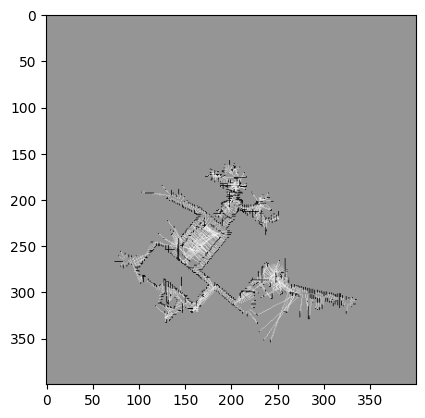

In [3]:
import lab1
import numpy as np
%matplotlib inline

map_size = 100
map_res = 0.25

prior = 0.50
prob_occ = 0.90 # l0
prob_free = 0.35

# load data
ranges_raw = np.loadtxt("ranges.data", delimiter=',', dtype='float')
poses_raw = np.loadtxt("poses.data", delimiter=',', dtype='float')

# initialize gridmap 400x400
occ_gridmap = lab1.init_gridmap(map_size, map_res)+prior
occ_gridmap = lab1.grid_mapping_with_known_poses(ranges_raw, poses_raw, occ_gridmap, map_res, prob_occ, prob_free, prior)
lab1.plot_gridmap(occ_gridmap)